In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
# Read in dataset
df = pd.read_csv(r"C:\Users\GREAT\Downloads\water_potability.csv")
print(df.shape)
df.head()

(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
# Check for missing values
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [5]:
# Fill the missing values with the mean of the column
df.fillna(df.mean(), inplace = True)

In [6]:
# Check for missing values again
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [7]:
# Preview Dataset
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,3276.0,7.080795,1.469956,0.000000,6.277673,7.080795,7.870050,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,3276.0,333.775777,36.142612,129.000000,317.094638,333.775777,350.385756,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3276.0,66.396293,15.769881,0.738000,56.647656,66.396293,76.666609,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


### Exploratory Data Analysis

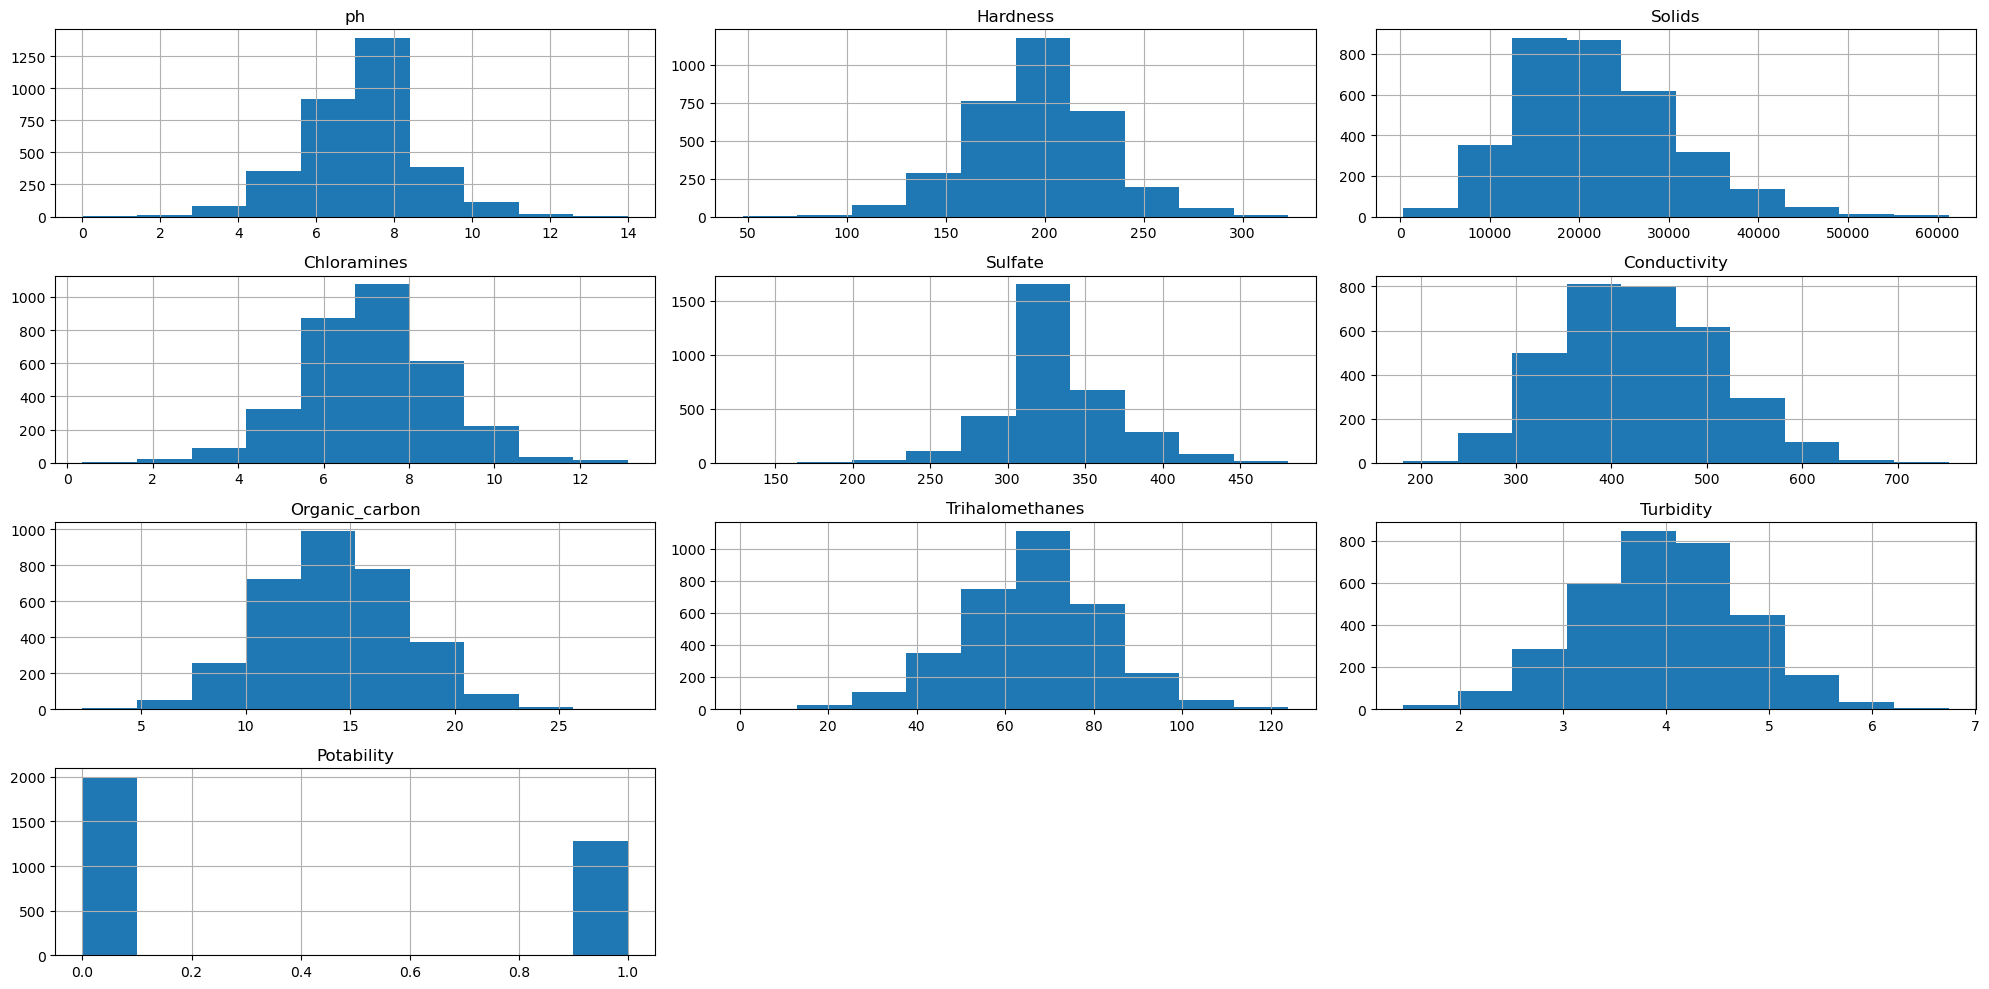

In [9]:
# Visualize all the columns
hist = df.hist(figsize = (20,10))
plt.tight_layout()

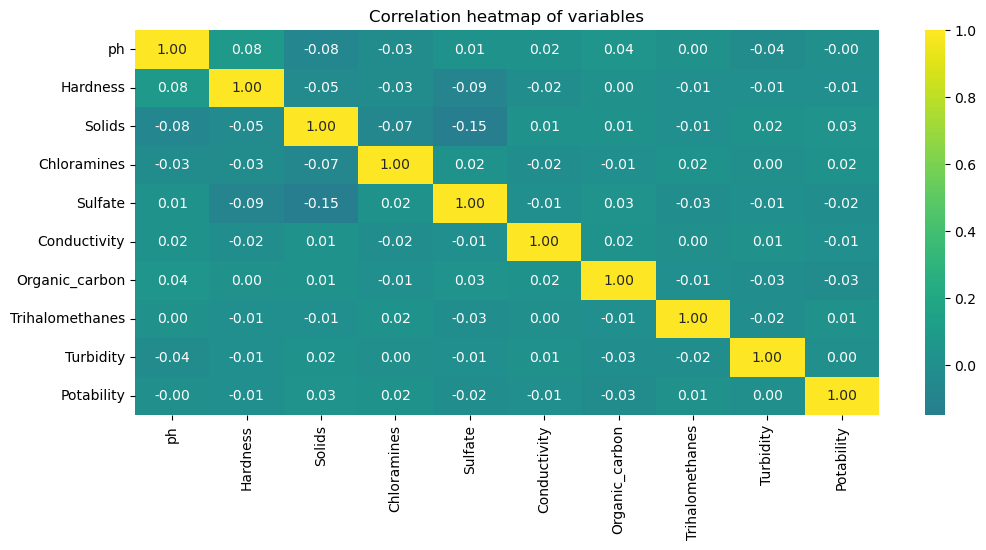

In [10]:
# Correlation between Variables and target column
plt.figure(figsize = (12,5))
sns.heatmap(df.corr(), annot= True, fmt = '.2f', cmap = 'viridis', center = 0)
plt.title('Correlation heatmap of variables', fontweight = 16);

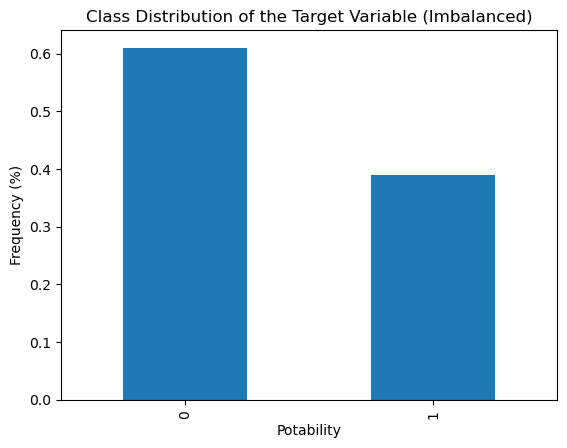

In [11]:
df['Potability'].value_counts(normalize = True).plot(
    kind = 'bar',
    title = 'Class Distribution of the Target Variable (Imbalanced)',
    ylabel = 'Frequency (%)'
);

In [12]:
# Address Class Imbalance by oversampling the minority class (1)
X = df.drop('Potability', axis=1)
y = df['Potability']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(X.shape, y.shape)
print(X_resampled.shape, y_resampled.shape)

(3276, 9) (3276,)
(3996, 9) (3996,)


In [13]:
# Check if the target column is balanced
y_resampled.value_counts()

Potability
0    1998
1    1998
Name: count, dtype: int64

In [14]:
# Split Oversampled data into Test and Train Sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3196, 9) (800, 9) (3196,) (800,)


## Models Training, Predictions and Evaluation

## Random Forest Classifier

In [15]:
rf_model = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
rf_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [16]:
rf_ypred = rf_model.predict(X_test)
print(metrics.classification_report(y_test, rf_ypred))

              precision    recall  f1-score   support

           0       0.70      0.71      0.71       394
           1       0.72      0.70      0.71       406

    accuracy                           0.71       800
   macro avg       0.71      0.71      0.71       800
weighted avg       0.71      0.71      0.71       800



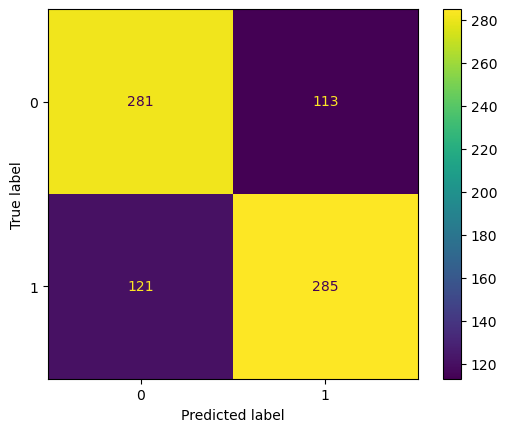

In [17]:
metrics.ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test);

### DecisionTree Classifier

In [18]:
dt_model = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42))
dt_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


              precision    recall  f1-score   support

           0       0.60      0.62      0.61       394
           1       0.62      0.59      0.60       406

    accuracy                           0.61       800
   macro avg       0.61      0.61      0.61       800
weighted avg       0.61      0.61      0.61       800



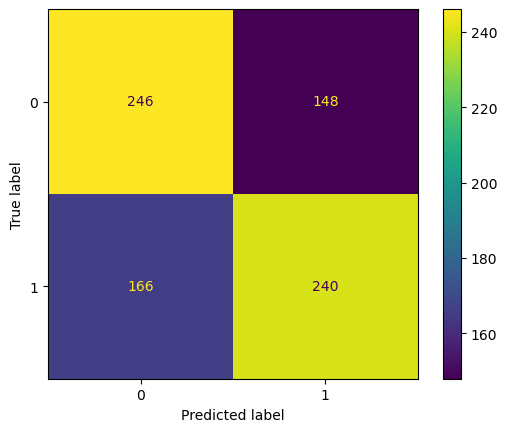

In [19]:
dt_ypred = dt_model.predict(X_test)
print(metrics.classification_report(y_test, dt_ypred))
metrics.ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test);

### Ridge Classifier

In [20]:
rg_model = make_pipeline(StandardScaler(),
                         RidgeClassifier(random_state = 42))
rg_model.fit(X_train, y_train)
rg_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('ridgeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


              precision    recall  f1-score   support

           0       0.51      0.57      0.54       394
           1       0.53      0.48      0.50       406

    accuracy                           0.52       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.52      0.52      0.52       800



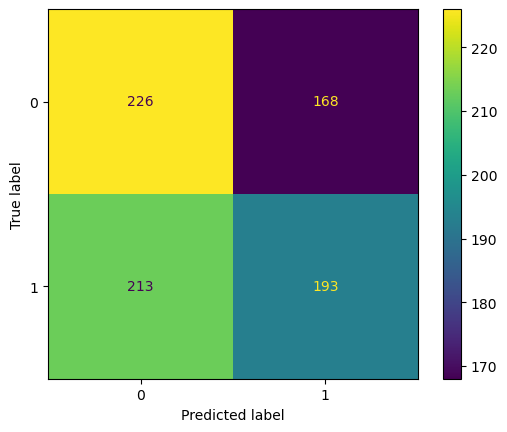

In [21]:
rg_ypred = rg_model.predict(X_test)
print(metrics.classification_report(y_test, rg_ypred))
metrics.ConfusionMatrixDisplay.from_estimator(rg_model, X_test, y_test);

### ExtraTree Classifier

In [22]:
et_model = make_pipeline(StandardScaler(),
                         ExtraTreeClassifier(random_state = 42))
et_model.fit(X_train, y_train)
et_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('extratreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'gini'
,splitter,'random'
,max_depth,None
,min_samples_split,2


              precision    recall  f1-score   support

           0       0.57      0.55      0.56       394
           1       0.58      0.60      0.59       406

    accuracy                           0.57       800
   macro avg       0.57      0.57      0.57       800
weighted avg       0.57      0.57      0.57       800



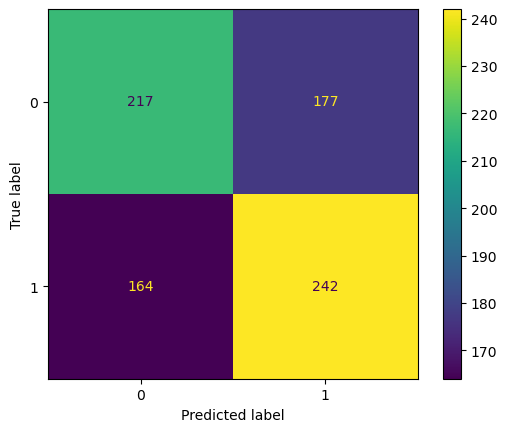

In [23]:
et_ypred = et_model.predict(X_test)
print(metrics.classification_report(y_test, et_ypred))
metrics.ConfusionMatrixDisplay.from_estimator(et_model, X_test, y_test);

### XGBOOST Classifier

In [24]:
xgb_model = make_pipeline(StandardScaler(),
                         XGBClassifier())
xgb_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('xgbclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


              precision    recall  f1-score   support

           0       0.57      0.55      0.56       394
           1       0.58      0.60      0.59       406

    accuracy                           0.57       800
   macro avg       0.57      0.57      0.57       800
weighted avg       0.57      0.57      0.57       800



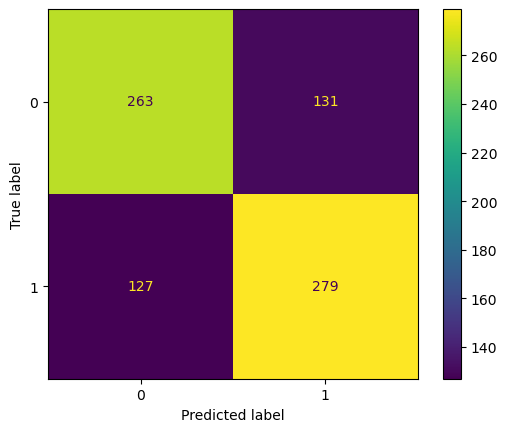

In [25]:
xgb_ypred = et_model.predict(X_test)
print(metrics.classification_report(y_test, xgb_ypred))
metrics.ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test);

### Hyperparameter Tuning for RandomForest Classifier

In [26]:
# Hyperparameter tuning for the best performing model (rf_model)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_.round(3))

# Evaluate best model on test set
rf_ypred_tuned = grid_search.best_estimator_.predict(X_test)
print(metrics.classification_report(y_test, rf_ypred_tuned))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.697
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       394
           1       0.73      0.72      0.73       406

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800



              precision    recall  f1-score   support

           0       0.72      0.73      0.72       394
           1       0.73      0.72      0.73       406

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800



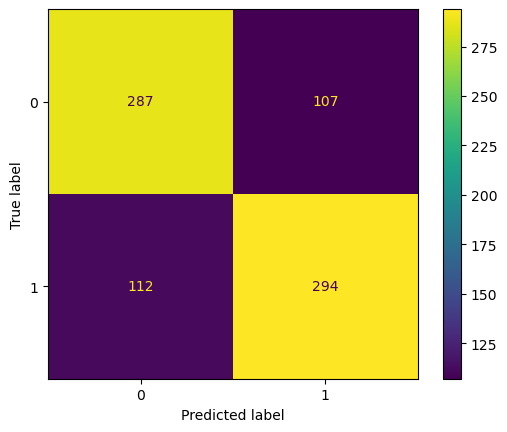

In [30]:
rf_ypred_tuned = grid_search.best_estimator_.predict(X_test)
print(metrics.classification_report(y_test, rf_ypred_tuned))
metrics.ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test);

### Feature Importances

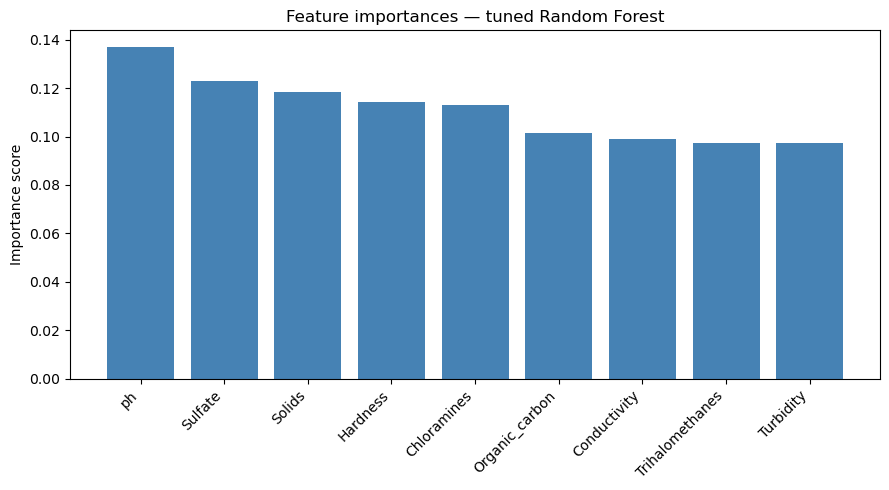


Feature ranking:
1. ph: 0.1370
2. Sulfate: 0.1229
3. Solids: 0.1182
4. Hardness: 0.1144
5. Chloramines: 0.1128
6. Organic_carbon: 0.1013
7. Conductivity: 0.0988
8. Trihalomethanes: 0.0974
9. Turbidity: 0.0973


In [31]:
# Get feature importances from best model
best_rf = grid_search.best_estimator_
importances = best_rf.feature_importances_
features = X.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(9, 5))
plt.bar(range(len(features)), importances[indices], color='steelblue', edgecolor='none')
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance score')
plt.title('Feature importances — tuned Random Forest')
plt.tight_layout()
plt.show()

# Print ranked list
print("\nFeature ranking:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {features[idx]}: {importances[idx]:.4f}")

In [32]:
# Save the best model
joblib.dump(grid_search.best_estimator_, 'groundwater_rf_model.pkl')

print("Model saved successfully.")

# To load and use it later
model = joblib.load('groundwater_rf_model.pkl')

# Test with a new sample (use actual values in practice)
new_sample = pd.DataFrame([{
    'ph': 7.2,
    'Hardness': 180.0,
    'Solids': 15000.0,
    'Chloramines': 6.5,
    'Sulfate': 320.0,
    'Conductivity': 400.0,
    'Organic_carbon': 12.0,
    'Trihalomethanes': 60.0,
    'Turbidity': 3.5
}])

prediction = model.predict(new_sample)
probability = model.predict_proba(new_sample)

print(f"Prediction: {'Potable' if prediction[0]== 1 else 'Not potable'}")
print(f"Confidence: {probability[0].max():.2%}")

Model saved successfully.
Prediction: Potable
Confidence: 52.14%
